<a href="https://colab.research.google.com/github/jonhnson248/extracao_com_lbp/blob/main/Extrator_lbp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from skimage import io, color
from skimage.feature import local_binary_pattern
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif


imagens_cinza = []
labels = []

# CARREGANDO A BASE DE DADOS PRÓPRIA DE ORQUÍDEAS
# Relacionando o nome da classe com o caminho da pasta
pasta = {
    'orquidea': 'dados_treino/orquideas',
    'girassol': 'dados_treino/girassois'
 }

for nome_classe, caminho_pasta in pasta.items():
  # Listando todos os arquivos dentro da pasta
  for nome_arquivo in os.listdir(caminho_pasta):
    caminho_completo = os.path.join(caminho_pasta, nome_arquivo)

    # Lê a imagem e converte para tons de cinza
    img_color = io.imread(caminho_completo)
    img_cinza = color.rgb2gray(img_color)

    # Guarda a imagem e a sua classe nas listas
    imagens_cinza.append(img_cinza)
    labels.append(nome_classe)

print(f"Total de imagens carregadas: {len(imagens_cinza)}")
print(f"Rótulos carregados: {labels}")


# CONFIGURANDO O ACESSO E BAIXANDO A BASE DE DADS DE RACHADURAS EM SUPERFÍCIES
# Cria o diretório oculto e armazena o token de acesso de forma segura
!mkdir -p ~/.kaggle && echo KGAT_d42d739651979ecfed36e15c0afa2d08 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
# Listagem das competições
!kaggle competitions list
# Baixa o arquivo zip do dataset do Kaggle
!kaggle datasets download -d arunrk7/surface-crack-detection
# Descompacta o arquivo baixado de forma silenciosa para liberar as pastas de imagens
!unzip -q surface-crack-detection.zip

concreto_cinza = []
labels_concreto = []

# Caminho para a pasta de imagens com rachaduras
pasta_positivo = 'Positive'
# Listagem com os 100 primeiros arquivos para não travar a memória
arquivos_positivos = os.listdir(pasta_positivo)[:100]

for nome_arquivo in arquivos_positivos:
    caminho_completo = os.path.join(pasta_positivo, nome_arquivo)
    # Lê a imagem diretamente em tons de cinza
    imagem = cv2.imread(caminho_completo, 0)

    concreto_cinza.append(imagem)
    labels_concreto.append('rachadura')

# Caminho para a pasta de imagens intactas
pasta_negativo = 'Negative'
arquivos_negativo = os.listdir(pasta_negativo)[:100]

for nome_arquivo in arquivos_negativo:
    caminho_completo = os.path.join(pasta_negativo, nome_arquivo)
    imagem = cv2.imread(caminho_completo, 0)

    concreto_cinza.append(imagem)
    labels_concreto.append('intacta')

print(f"Total de fotos carregadas: {len(concreto_cinza)}")
print(f"Primeiros 10 gabaritos: {labels_concreto[:10]}")
print(f"Últimos 10 gabaritos: {labels_concreto[-10:]}")

Total de imagens carregadas: 10
Rótulos carregados: ['orquidea', 'orquidea', 'orquidea', 'orquidea', 'orquidea', 'girassol', 'girassol', 'girassol', 'girassol', 'girassol']
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challen

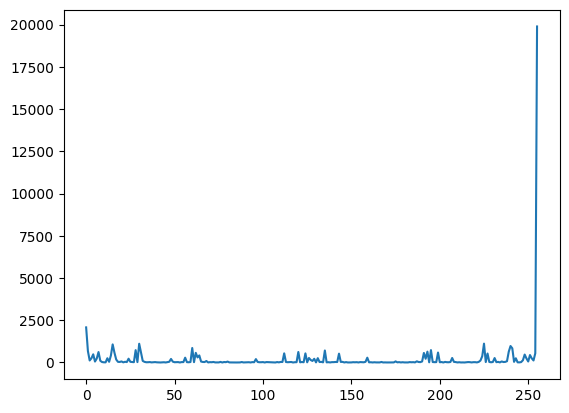

In [ ]:
# Lista vazia para guardar os resumos matemáticos de cada foto
histograma = []

for imagem_atual in imagens_cinza:
  # Extrai os padrões de textura
  imagem_lbp = local_binary_pattern(imagem_atual, 8, 1)
  # Conta a frequência da cada um dos 256 códigos de textura possíveis
  frequencia_textura, _ = np.histogram(imagem_lbp, bins = 256, range = (0, 256))
  histograma.append(frequencia_textura)

# Cria o gráfico da primeira foto (para outras fotos tem que atualizar o código)
plt.plot(histograma[0])
plt.show()

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(histograma, labels, test_size=0.20)

# Criação do KNN
knn = KNeighborsClassifier(n_neighbors = 3)

# Treinamento e Teste do KNN
knn.fit(X_treino, y_treino)
previsoes = knn.predict(X_teste)

# Comparação do gabarito real com as previsões do KNN para saber a taxa de acerto
taxa_acerto = accuracy_score(y_teste, previsoes)
print(f"A taxa de acerto do modelo foi: {taxa_acerto}")

A taxa de acerto do modelo foi: 1.0


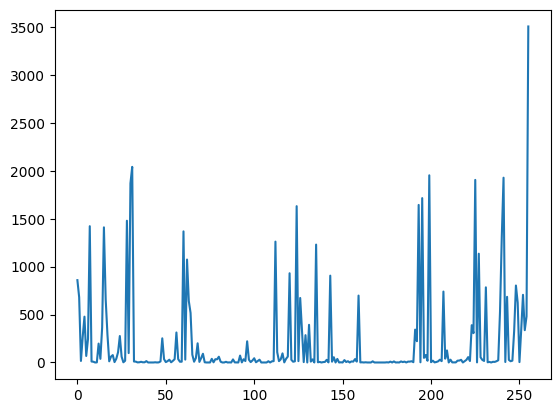

In [ ]:
histograma_concreto = []

for imagem_atual in concreto_cinza:
  imagem_lbp = local_binary_pattern(imagem_atual, 8, 1)

  frequencia_textura, _ = np.histogram(imagem_lbp, bins = 256, range = (0, 256))
  histograma_concreto.append(frequencia_textura)

plt.plot(histograma_concreto[0])
plt.show()

A taxa de acerto do modelo foi: 0.75


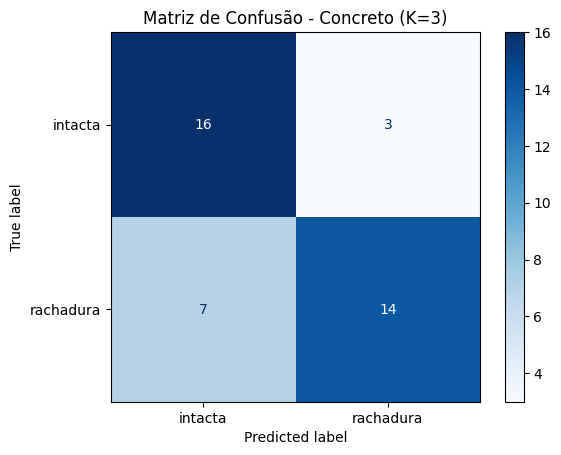

In [ ]:
X_treino_concreto, X_teste_concreto, y_treino_concreto, y_teste_concreto = train_test_split(histograma_concreto, labels_concreto, test_size=0.20)

knn_concreto = KNeighborsClassifier(n_neighbors = 3)

knn_concreto.fit(X_treino_concreto, y_treino_concreto)
previsoes_concreto = knn_concreto.predict(X_teste_concreto)

taxa_acerto_concreto = accuracy_score(y_teste_concreto, previsoes_concreto)
print(f"A taxa de acerto do modelo foi: {taxa_acerto_concreto}")

# Calcula os números da matriz comparando o gabarito real com as previsões
matriz_concreto = confusion_matrix(y_teste_concreto, previsoes_concreto, labels=['intacta', 'rachadura'])

# Desenha o gráfico coloridinho
grafico = ConfusionMatrixDisplay(confusion_matrix = matriz_concreto, display_labels=['intacta', 'rachadura'])
grafico.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusão - Concreto (K=3)")
plt.show()

In [ ]:
medias_por_k = []

for k in range(1, 11):
    notas_das_rodadas = [] # Esvazia o colecionador para o novo K

    for rodada in range(1, 31):
        # Divisão aleatória a cada rodada
        X_treino_c, X_teste_c, y_treino_c, y_teste_c = train_test_split(histograma_concreto, labels_concreto, test_size=0.20)

        knn_c = KNeighborsClassifier(n_neighbors = k)

        knn_c.fit(X_treino_c, y_treino_c)
        previsoes_c = knn_c.predict(X_teste_c)

        taxa_acerto_c = accuracy_score(y_teste_c, previsoes_c)
        notas_das_rodadas.append(taxa_acerto_c)

    # Calcula a média das 30 notas desse K
    media_deste_k = np.mean(notas_das_rodadas)
    medias_por_k.append(media_deste_k)
    print(f"K={k} | Acurácia Média: {media_deste_k:.4f}")

K=1 | Acurácia Média: 0.6533
K=2 | Acurácia Média: 0.6042
K=3 | Acurácia Média: 0.6858
K=4 | Acurácia Média: 0.6533
K=5 | Acurácia Média: 0.6733
K=6 | Acurácia Média: 0.6733
K=7 | Acurácia Média: 0.6750
K=8 | Acurácia Média: 0.7092
K=9 | Acurácia Média: 0.6917
K=10 | Acurácia Média: 0.6942


A taxa de acerto do modelo foi: 0.775


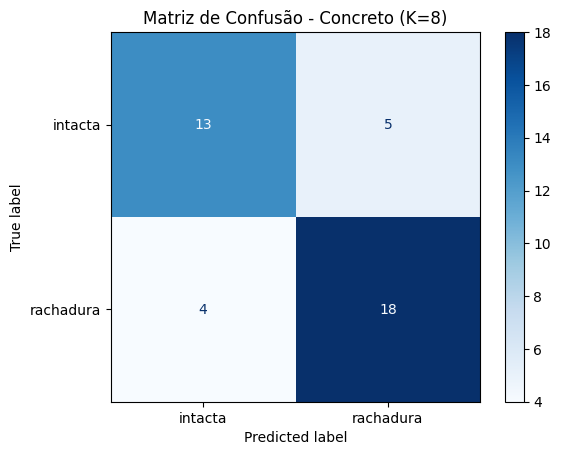

In [ ]:
X_treino_cct, X_teste_cct, y_treino_cct, y_teste_cct = train_test_split(histograma_concreto, labels_concreto, test_size=0.20)

knn_cct = KNeighborsClassifier(n_neighbors = 8)

knn_cct.fit(X_treino_cct, y_treino_cct)
previsoes_cct = knn_cct.predict(X_teste_cct)

taxa_acerto_cct = accuracy_score(y_teste_cct, previsoes_cct)
print(f"A taxa de acerto do modelo foi: {taxa_acerto_cct}")

matriz_cct = confusion_matrix(y_teste_cct, previsoes_cct, labels = ['intacta', 'rachadura'])

grafico_cct = ConfusionMatrixDisplay(confusion_matrix = matriz_cct, display_labels = ['intacta', 'rachadura'])
grafico_cct.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusão - Concreto (K=8)")
plt.show()

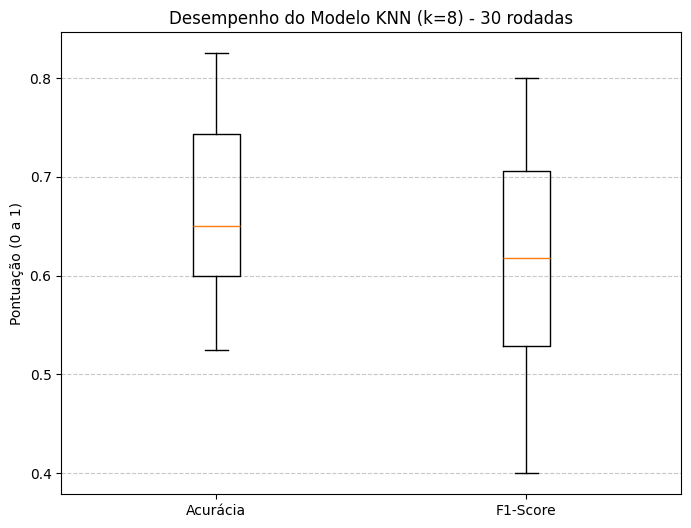

In [ ]:
lista_acuracia = []
lista_f1_score = []

for rodada in range(1, 31):
  X_treino_cct, X_teste_cct, y_treino_cct, y_teste_cct = train_test_split(histograma_concreto, labels_concreto, test_size=0.20)

  knn_cct = KNeighborsClassifier(n_neighbors = 8)

  knn_cct.fit(X_treino_cct, y_treino_cct)
  previsoes_cct = knn_cct.predict(X_teste_cct)

  acuracia = accuracy_score(y_teste_cct, previsoes_cct)
  lista_acuracia.append(acuracia)
  f1 = f1_score(y_teste_cct, previsoes_cct, pos_label = 'rachadura')
  lista_f1_score.append(f1)

plt.figure(figsize = (8, 6))
plt.boxplot([lista_acuracia, lista_f1_score], labels = ['Acurácia', 'F1-Score'])
plt.title('Desempenho do Modelo KNN (k=8) - 30 rodadas')
plt.ylabel('Pontuação (0 a 1)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

In [ ]:
print("Calculando o t-SNE (Isso pode levar alguns segundinhos)...")

# Configurando o t-SNE para "esmagar" os dados em 3 dimensões
tsne = TSNE(n_components = 3, random_state = 42)
# Aplicando a transformação no nosso histograma completo
# O np.array() transforma a lista em uma matriz que o scikit-learn entende!
dados_3d = tsne.fit_transform(np.array(histograma_concreto))

# Criando uma tabela organizada (DataFrame) para o Plotly entender
df_tsne = pd.DataFrame(dados_3d, columns = ['Eixo X', 'Eixo Y', 'Eixo Z'])
# Adicionando o gabarito (intacta/rachadura) para ele pintar de cores diferentes
df_tsne['Classe'] = labels_concreto

# 5. Desenhando o gráfico 3D interativo!
fig = px.scatter_3d(df_tsne, x = 'Eixo X', y = 'Eixo Y', z = 'Eixo Z',
                    color = 'Classe',
                    title = 'Visualização 3D das Texturas (t-SNE)',
                    color_discrete_sequence = ['#1f77b4', '#d62728']) # Azul e Vermelho

fig.show()

Calculando o t-SNE (Isso pode levar alguns segundinhos)...


Calculando as notas da ANOVA...


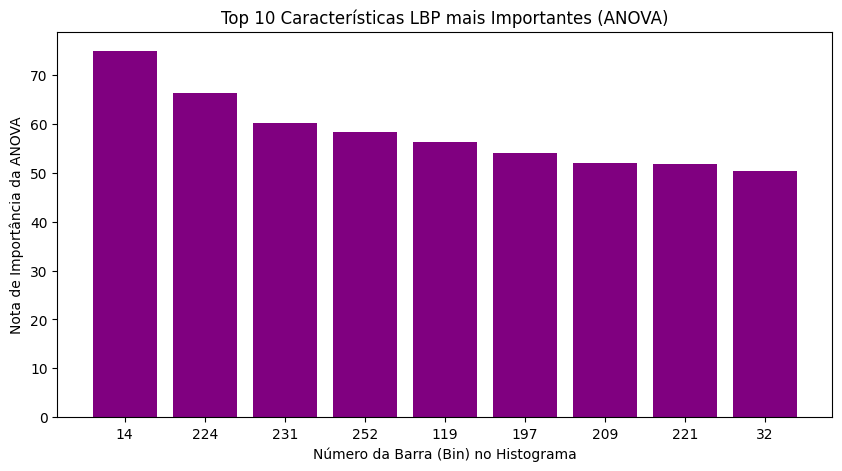

In [ ]:
print("Calculando as notas da ANOVA...")

# Chama o "juiz"
juiz_anova = SelectKBest(score_func = f_classif, k = 'all')

# O juiz analisa todos os nossos dados
juiz_anova.fit(histograma_concreto, labels_concreto)

# Pegam as notas (scores) que ele deu para cada barra do LBP
notas = juiz_anova.scores_

# Um pequeno truque para descobrir o número das 10 barras com as maiores notas
# (O argsort organiza da menor nota para a maior, então pegamos as 10 últimas de trás pra frente)
top_10_posicoes = np.argsort(notas)[-10:][::-1]
top_10_notas = notas[top_10_posicoes]

# 5. Desenhando o pódio em formato de gráfico de barras
plt.figure(figsize = (10, 5))
plt.bar([str(i) for i in top_10_posicoes], top_10_notas, color = 'purple')
plt.title('Top 10 Características LBP mais Importantes (ANOVA)')
plt.xlabel('Número da Barra (Bin) no Histograma')
plt.ylabel('Nota de Importância da ANOVA')
plt.show()